# Perceptrón multicapa para clasificación — `MLPClassifier` sobre Iris

**Módulo 06 — Fundamentos de redes neuronales.** Recurso descargable de la clase (`OD_RN1_ESP_M03_S10`), ampliado con explicaciones, diagnóstico del entrenamiento y comparación contra el perceptrón simple.

## Objetivo

Clasificar las **tres** especies de iris (*setosa*, *versicolor*, *virginica*) con un **perceptrón multicapa**, y ver qué gana respecto del perceptrón simple del notebook anterior.

## Por qué acá sí van las tres clases

En [`perceptron_iris_sklearn.ipynb`](perceptron_iris_sklearn.ipynb) tuvimos que recortar el problema a **dos** clases linealmente separables, porque esas son las limitaciones del perceptrón simple. El MLP levanta las dos restricciones a la vez:

| Limitación del perceptrón simple | Cómo la resuelve el MLP |
|---|---|
| Salida binaria (0 o 1) | capa de salida con una neurona por clase |
| Solo problemas linealmente separables | capas ocultas + activación no lineal → frontera curva |

*Versicolor* y *virginica* **se solapan** con estos dos atributos: no hay recta que las separe. Esa es exactamente la situación que motiva el modelo.

## Relación con la teoría

- [`Perceptrón Multicapa.md`](../teoria/Perceptrón%20Multicapa.md) — arquitectura, forward propagation y backpropagation.
- [`Limitaciones.md`](../teoria/Limitaciones.md) — qué no puede el perceptrón simple.

## Qué se agregó al recurso original

El notebook de la clase eran 13 celdas de código sin una sola línea de texto. Acá se suma: explicación de cada hiperparámetro, diagnóstico de convergencia (`n_iter_`, `loss_curve_`), inspección de la arquitectura real de la red, comparación explícita contra el perceptrón simple sobre el **mismo** dataset, la advertencia sobre **escalado** que el original omite, y matriz de confusión leída clase por clase.

## 1. Librerías

In [1]:
from sklearn.datasets import load_iris
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import Perceptron
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

SEMILLA = 42

## 2. Cargar el dataset

Iris otra vez, pero ahora **completo**: las 150 flores y las 3 especies.

In [2]:
iris = load_iris()

data_df = pd.DataFrame(iris.data, columns=iris.feature_names)
data_df["target"] = iris.target

print("Clases:", dict(enumerate(iris.target_names)))
print("Muestras por clase:")
print(data_df["target"].value_counts().sort_index())
data_df.head()

Clases: {0: np.str_('setosa'), 1: np.str_('versicolor'), 2: np.str_('virginica')}
Muestras por clase:
target
0    50
1    50
2    50
Name: count, dtype: int64


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


## 3. Seleccionar los dos atributos

Igual que antes, nos quedamos con dos atributos para poder **dibujar** la frontera de decisión en un plano. No es una necesidad del modelo (el MLP acepta los cuatro sin problema), es para poder ver lo que hace.

> El recurso original deja comentada la alternativa `["sepal width (cm)", "petal width (cm)"]`. Vale la pena probarla después: con el ancho, las clases se solapan más y se ve mejor cómo el MLP curva la frontera.

In [3]:
columnas = ["sepal length (cm)", "petal length (cm)", "target"]
data_df = data_df[columnas]

data_df.tail()

,sepal length (cm),petal length (cm),target
145,6.7,5.2,2
146,6.3,5.0,2
147,6.5,5.2,2
148,6.2,5.4,2
149,5.9,5.1,2


## 4. Visualizar: dónde está el problema

Acá se ve por qué el perceptrón simple no alcanza.

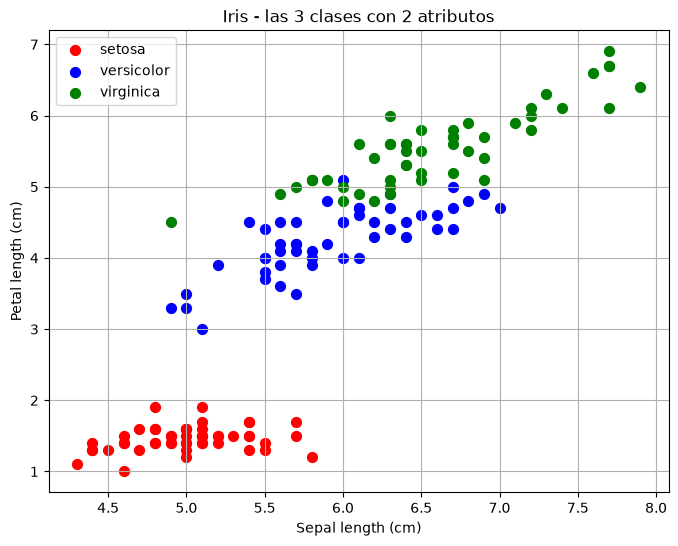

In [4]:
setosa_data = data_df[data_df["target"] == 0]
versicolor_data = data_df[data_df["target"] == 1]
virginica_data = data_df[data_df["target"] == 2]

plt.figure(figsize=(8, 6))
plt.scatter(setosa_data["sepal length (cm)"], setosa_data["petal length (cm)"],
            label="setosa", color="red", s=50)
plt.scatter(versicolor_data["sepal length (cm)"], versicolor_data["petal length (cm)"],
            label="versicolor", color="blue", s=50)
plt.scatter(virginica_data["sepal length (cm)"], virginica_data["petal length (cm)"],
            label="virginica", color="green", s=50)

plt.title("Iris - las 3 clases con 2 atributos")
plt.xlabel("Sepal length (cm)")
plt.ylabel("Petal length (cm)")
plt.grid()
plt.legend()
plt.show()

**Lo que hay que mirar:** *setosa* (rojo) está perfectamente aislada — esa parte es fácil. Pero *versicolor* (azul) y *virginica* (verde) **se tocan y se mezclan** en la zona del medio. No existe una recta que las separe: ese solapamiento es el problema real, y es lo que el perceptrón simple no puede resolver.

## 5. Atributos y etiquetas

In [5]:
X = data_df[["sepal length (cm)", "petal length (cm)"]].values
y = data_df["target"].values

print("X:", X.shape, "| y:", y.shape)
print("Etiquetas presentes:", np.unique(y))

X: (150, 2) | y: (150,)
Etiquetas presentes: [0 1 2]


## 6. División train / test

`stratify=y` es más importante acá que con dos clases: garantiza que las tres especies estén representadas proporcionalmente en el conjunto de prueba.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEMILLA, stratify=y
)

print("Entrenamiento:", X_train.shape[0], "| Prueba:", X_test.shape[0])
print("Clases en test:", np.bincount(y_test))

Entrenamiento: 120 | Prueba: 30
Clases en test: [10 10 10]


## 7. Escalar los atributos

**El recurso original salta este paso**, y conviene no saltarlo. La teoría lo dice explícitamente: las redes multicapa son *sensibles a la calidad y la naturaleza de los datos de entrada*.

El motivo es que el entrenamiento por descenso de gradiente avanza mal cuando los atributos están en escalas distintas: la superficie de pérdida queda alargada y el optimizador zigzaguea. Acá ambos atributos están en centímetros y en rangos parecidos, así que **funciona igual sin escalar** — pero es un mal hábito para llevarse a datasets reales, donde las escalas nunca son homogéneas.

`fit_transform` sobre train y solo `transform` sobre test: el escalador aprende la media y el desvío **únicamente** del entrenamiento. Usar el test para calcularlos sería filtrar información (*data leakage*).

In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Media por atributo (train escalado):", X_train_scaled.mean(axis=0).round(3))
print("Desvio por atributo (train escalado):", X_train_scaled.std(axis=0).round(3))

Media por atributo (train escalado): [-0.  0.]
Desvio por atributo (train escalado): [1. 1.]


## 8. Entrenar el MLP

| Parámetro | Qué hace |
|---|---|
| `hidden_layer_sizes=(100, 150)` | dos capas ocultas: 100 neuronas la primera, 150 la segunda |
| `activation='relu'` | función de activación no lineal, `max(0, z)`. **Es lo que hace que apilar capas sirva** |
| `max_iter=300` | tope de épocas del optimizador |
| `random_state` | fija la inicialización aleatoria de los pesos → reproducible |

Sobre el tamaño: **250 neuronas para 120 muestras de entrenamiento es enormemente sobredimensionado**. Es la configuración del recurso original y la dejamos para poder compararlas, pero es justo el escenario de sobreajuste que advierte la teoría. En la sección 12 la comparamos contra redes mucho más chicas.

In [8]:
mlp = MLPClassifier(
    hidden_layer_sizes=(100, 150),
    activation="relu",
    max_iter=300,
    random_state=SEMILLA,
)
mlp.fit(X_train_scaled, y_train)

print("Epocas ejecutadas:", mlp.n_iter_, "de", mlp.max_iter)
print("Perdida final:", round(mlp.loss_, 4))

Epocas ejecutadas: 224 de 300
Perdida final: 0.0592


> Si aparece un `ConvergenceWarning`, significa que el optimizador llegó a `max_iter` sin estabilizarse. No es un error: el modelo entrenado sirve igual, pero avisa que con más épocas podría mejorar.

## 9. La arquitectura que se armó realmente

`coefs_` contiene las matrices de pesos entre capas consecutivas. Mirarlas confirma la estructura descrita en la teoría y da la dimensión real del modelo.

In [9]:
print("Capas de pesos:", len(mlp.coefs_))
for i, W in enumerate(mlp.coefs_):
    print(f"  capa {i}: {W.shape[0]} entradas -> {W.shape[1]} salidas")

total = sum(W.size for W in mlp.coefs_) + sum(b.size for b in mlp.intercepts_)
print(f"\nParametros entrenables: {total:,}")
print(f"Muestras de entrenamiento: {X_train.shape[0]}")
print("\nEl perceptron simple del notebook anterior tenia 3 parametros (w1, w2, b).")

Capas de pesos: 3
  capa 0: 2 entradas -> 100 salidas
  capa 1: 100 entradas -> 150 salidas
  capa 2: 150 entradas -> 3 salidas

Parametros entrenables: 15,903
Muestras de entrenamiento: 120

El perceptron simple del notebook anterior tenia 3 parametros (w1, w2, b).


Miles de parámetros para 120 muestras. Esa desproporción es la razón por la que un MLP **necesita muchos datos** y por la que la interpretabilidad se pierde: en el perceptrón simple podíamos leer los tres números y entender la regla; acá no.

## 10. La curva de pérdida

`loss_curve_` guarda la pérdida época por época. Es la herramienta de diagnóstico principal del entrenamiento.

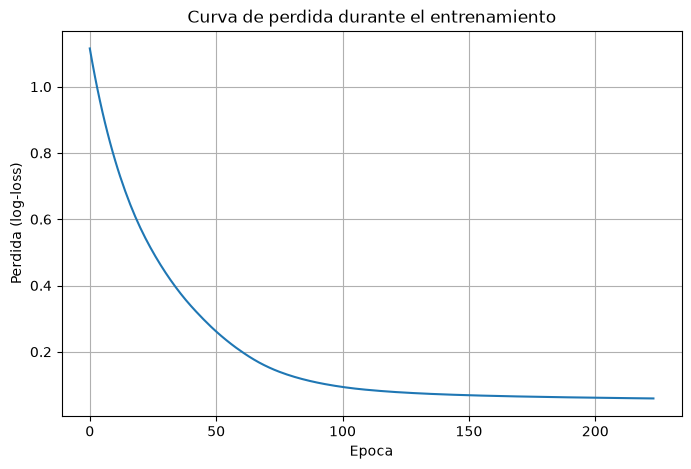

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(mlp.loss_curve_)
plt.title("Curva de perdida durante el entrenamiento")
plt.xlabel("Epoca")
plt.ylabel("Perdida (log-loss)")
plt.grid()
plt.show()

**Cómo leerla:** debe **bajar y aplanarse**. Si baja y se estanca alto, el modelo no aprende (poca capacidad, o tasa de aprendizaje mal elegida). Si sigue bajando abruptamente al llegar al final, faltaron épocas. Si oscila, la tasa de aprendizaje es demasiado alta.

Ojo con una trampa: esta curva es de la pérdida **sobre el entrenamiento**. Que baje hasta casi cero no dice nada sobre generalización — puede ser justamente la señal de que memorizó.

## 11. Predecir y evaluar

In [11]:
y_pred = mlp.predict(X_test_scaled)

print("Real:    ", y_test)
print("Predicho:", y_pred)

accuracy = accuracy_score(y_test, y_pred) * 100
print(f"\nExactitud: {accuracy:.2f}%")

Real:     [0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 1 1 0 2 0]
Predicho: [0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 1 0 2 1 2 2 2 1 0 2 0]

Exactitud: 93.33%


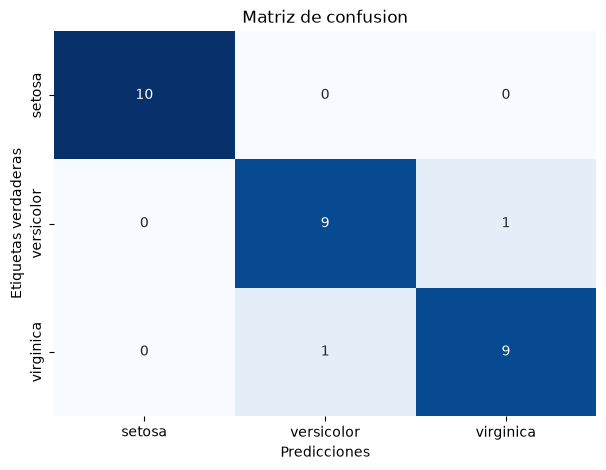

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



In [12]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="g", cmap="Blues", cbar=False,
            xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel("Predicciones")
plt.ylabel("Etiquetas verdaderas")
plt.title("Matriz de confusion")
plt.show()

print(classification_report(y_test, y_pred, target_names=iris.target_names))

**Cómo leer la matriz:** la diagonal son los aciertos; todo lo que está fuera son errores. Lo esperable es que *setosa* salga perfecta (está aislada) y que los errores, si los hay, se concentren en la celda versicolor ↔ virginica: son las dos clases que se solapan en el gráfico de la sección 4.

Del reporte, por clase: **precision** = de los que predije como esta clase, cuántos lo eran. **Recall** = de los que realmente eran de esta clase, cuántos detecté. **F1** = su media armónica.

## 12. ¿Hacen falta 250 neuronas?

Comparación directa contra dos redes mucho más chicas, con la misma receta.

In [13]:
resultados = [{"modelo": "MLP (100, 150)", "parametros": total,
               "exactitud test": accuracy_score(y_test, y_pred)}]

for tamano in [(5,), (20,)]:
    m = MLPClassifier(hidden_layer_sizes=tamano, activation="relu",
                      max_iter=2000, random_state=SEMILLA)
    m.fit(X_train_scaled, y_train)
    n_par = sum(W.size for W in m.coefs_) + sum(b.size for b in m.intercepts_)
    resultados.append({
        "modelo": f"MLP {tamano}",
        "parametros": n_par,
        "exactitud test": accuracy_score(y_test, m.predict(X_test_scaled)),
    })

pd.DataFrame(resultados).sort_values("parametros").reset_index(drop=True)

,modelo,parametros,exactitud test
0,"MLP (5,)",33,0.800000
1,"MLP (20,)",123,0.933333
2,"MLP (100, 150)",15903,0.933333


Lo que muestra la tabla es una **curva de capacidad**, no una recta:

- Con **5 neuronas** el modelo se queda corto: no tiene capacidad suficiente para curvar la frontera en la zona donde versicolor y virginica se solapan. Es **subajuste** (*underfitting*).
- Con **20 neuronas** —dos órdenes de magnitud menos parámetros que la red grande— el resultado ya es competitivo. Ese es el punto: casi toda la mejora se consigue mucho antes de llegar a 250 neuronas.
- Con **250 neuronas** el modelo llega arriba, pero con ~16.000 parámetros para 120 muestras. Funciona en un dataset fácil como este; en uno con ruido, esa desproporción es sobreajuste esperando ocurrir.

La lección no es "más chico es mejor" sino que **el tamaño de la red es un hiperparámetro a buscar**: hay un mínimo por debajo del cual el modelo no alcanza, y un punto a partir del cual agregar neuronas solo suma costo de cómputo y riesgo de sobreajuste.

## 13. Las regiones de decisión

Con dos atributos podemos evaluar el modelo sobre una grilla que cubre todo el plano y pintar cada punto según la clase que predice. El resultado son las **regiones de decisión**.

Detalle importante: la grilla se construye en el espacio original y hay que pasarla por el **mismo `scaler`** antes de predecir, porque el modelo fue entrenado con datos escalados.

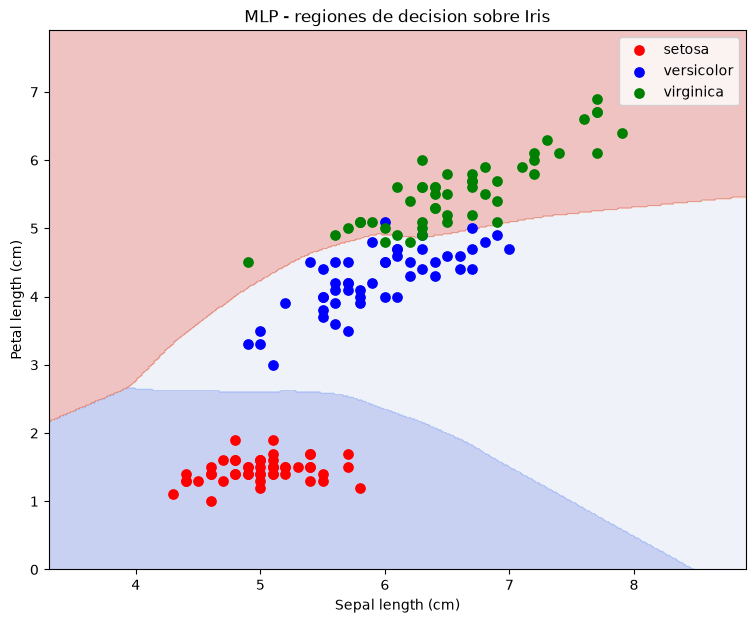

In [14]:
xx, yy = np.meshgrid(
    np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 400),
    np.linspace(X[:, 1].min() - 1, X[:, 1].max() + 1, 400),
)
grilla = scaler.transform(np.c_[xx.ravel(), yy.ravel()])
Z = mlp.predict(grilla).reshape(xx.shape)

plt.figure(figsize=(9, 7))
plt.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color="red", label="setosa", s=45)
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color="blue", label="versicolor", s=45)
plt.scatter(X[y == 2][:, 0], X[y == 2][:, 1], color="green", label="virginica", s=45)

plt.xlabel("Sepal length (cm)")
plt.ylabel("Petal length (cm)")
plt.title("MLP - regiones de decision sobre Iris")
plt.legend()
plt.show()

**Este gráfico es la conclusión del notebook.** Las fronteras **no son rectas**: se doblan para acomodarse a la zona donde versicolor y virginica se mezclan. Eso es exactamente lo que aportan las capas ocultas con activación no lineal, y es lo que el perceptrón simple —que solo puede trazar una recta— no puede hacer.

## 14. Comparación directa contra el perceptrón simple

Mismo dataset, mismo split, mismos datos escalados. Solo cambia el modelo.

In [15]:
perceptron = Perceptron(max_iter=1000, eta0=0.05, random_state=SEMILLA)
perceptron.fit(X_train_scaled, y_train)
pred_perceptron = perceptron.predict(X_test_scaled)

comparacion = pd.DataFrame({
    "modelo": ["Perceptron simple", "MLP (100, 150)"],
    "frontera": ["lineal (recta)", "no lineal (curva)"],
    "exactitud test": [accuracy_score(y_test, pred_perceptron), accuracy_score(y_test, y_pred)],
})
comparacion

,modelo,frontera,exactitud test
0,Perceptron simple,lineal (recta),0.766667
1,"MLP (100, 150)",no lineal (curva),0.933333


> Nota: `sklearn` aplica *one-vs-rest* internamente para que el perceptrón simple pueda manejar 3 clases — entrena un clasificador binario por clase. Aun así cada frontera sigue siendo una recta, y por eso no llega a separar bien versicolor de virginica.

## 15. Conclusiones

- El MLP resuelve lo que el perceptrón simple no puede: **múltiples clases** y **fronteras no lineales**.
- La no linealidad viene de la **función de activación** de las capas ocultas. Sin ella, apilar capas es equivalente a una sola capa lineal.
- Lo que se paga: muchos más parámetros, necesidad de más datos, pérdida de interpretabilidad, riesgo de sobreajuste y sensibilidad al escalado.
- `loss_curve_` y `n_iter_` son las herramientas para saber si el entrenamiento **efectivamente convergió**, y conviene mirarlas siempre.
- **El tamaño de la red se busca, no se maximiza**: 5 neuronas se quedaron cortas (subajuste), pero 20 ya fueron competitivas contra 250 usando una fracción de los parámetros.

## 16. Para seguir practicando

1. Cambiar a los atributos comentados en la sección 3 (`sepal width`, `petal width`). ¿Se solapan más las clases? ¿Cambia la forma de la frontera?
2. Poner `activation='identity'` (sin no linealidad). Las fronteras deberían volverse **rectas**: es la demostración práctica de por qué hace falta la activación no lineal.
3. Entrenar sin escalar (`X_train` en lugar de `X_train_scaled`). Comparar `n_iter_` y la pérdida final.
4. Usar los **cuatro** atributos. ¿Sube la exactitud? (El gráfico de regiones ya no se puede hacer.)
5. Subir `alpha` (regularización L2) a `1.0` y ver cómo se **suavizan** las fronteras.